In [2]:
from Lim_solver import smart_optimise
from neumann_rates import raw_overpass, raw_overpass_instant
import numpy as np
import matplotlib.pyplot as plt 
from tqdm import tqdm

In [17]:
angle_range=np.arange(30, 155,5)
loss_profiles = [np.loadtxt(f"up_link_passes/Total_Uplink_Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"up_link_passes/Total_Uplink_Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]

# Finite key per overpass as function of maximum elevation

24it [00:39,  1.65s/it]
24it [00:38,  1.59s/it]


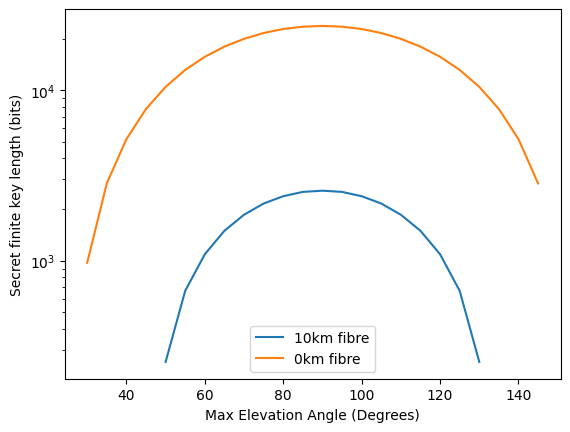

In [28]:
# with 10km fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
plt.plot(angle_range, skl, label="10km fibre")

# without fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
plt.plot(angle_range, skl, label="0km fibre")
plt.xlabel("Max Elevation Angle (Degrees)")
plt.ylabel("Secret finite key length (bits)")
plt.yscale("log")
plt.legend()

# Raw keysizes

17it [00:03,  5.09it/s]
17it [00:03,  5.12it/s]


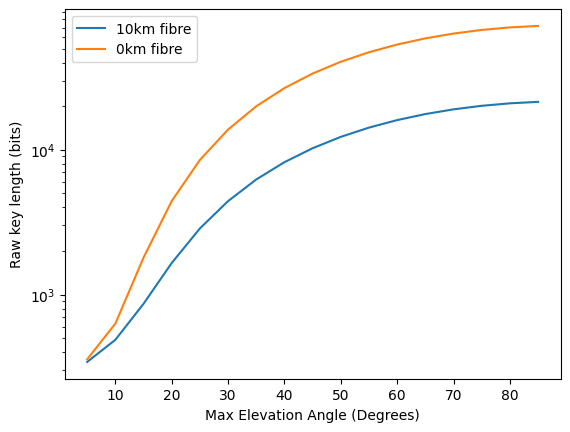

In [ ]:
# with 10km fibre
ms = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    ms+=[m]
plt.plot(angle_range, ms, label="10km fibre")

# without fibre
ms = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    ms+=[m]
plt.plot(angle_range, ms, label="0km fibre")
plt.xlabel("Max Elevation Angle (Degrees)")
plt.ylabel("Raw key length (bits)")
plt.yscale("log")
plt.legend()

# overpass losses as function of the max elevation angle

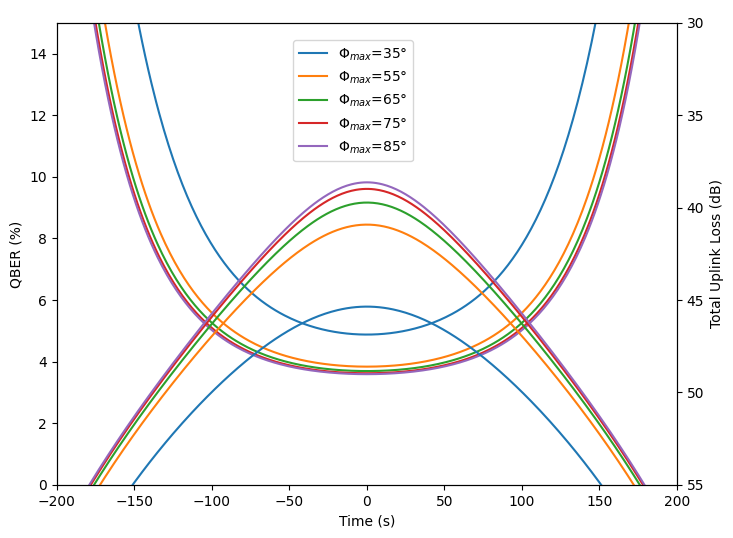

In [24]:
params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
f, a1  = plt.subplots(1, 1, figsize=(8, 6))
a2 = a1.twinx()
a2.invert_yaxis()
for i,prof in enumerate(loss_profiles):
    if not angle_range[i] in [85,75,65,55,35]:continue
    qber, qx, m = raw_overpass_instant(params, prof[:,1]+prof[:,2])
    a2.plot(prof[:,0], prof[:,1]+prof[:,2], label=rf"$\Phi_{{max}}$={angle_range[i]}°")
    a1.plot(prof[:,0], qber*100)
a1.set_xlim(-200, 200)
a1.set_xlabel("Time (s)")
a1.set_ylabel("QBER (%)")
a1.set_ylim(0, 15)

a2.set_xlim(-200, 200)
a2.set_xlabel("Time (s)")
a2.set_ylabel("Total Uplink Loss (dB)")
a2.set_ylim(55, 30)
f.legend(loc=[0.4,0.7])

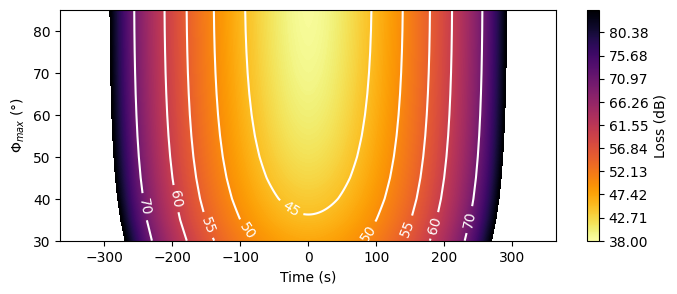

In [78]:
params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
angle_range=np.arange(30, 90, 5)
loss_profiles = [np.loadtxt(f"up_link_passes/Total_Uplink_Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"up_link_passes/Total_Uplink_Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]
plt.figure(figsize=(8,3))

X, Y = np.meshgrid(loss_profiles[np.argmax([p.shape[0] for p in loss_profiles])][:,0], angle_range)
Zloss = []
max_length = np.max([p.shape[0] for p in loss_profiles])
for prof in loss_profiles:

    buffer_length = (max_length - prof[:,0].shape[0])//2
    if prof[:,0].shape[0]%2 == max_length%2:
        Zloss.append(np.pad(prof[:,1]+prof[:,2], (buffer_length, buffer_length),"constant",constant_values=np.nan))
    else:
        Zloss.append(np.pad(prof[:,1]+prof[:,2], (buffer_length+1, buffer_length), "constant", constant_values=np.nan))
# plt.ylim(30, 90)
CS=plt.contour(X, Y, Zloss,levels=[45,50,55,60,70],colors="white")
plt.contourf(X, Y, Zloss,levels=np.linspace(38,85,500), cmap="inferno_r")

plt.colorbar(label="Loss (dB)")

plt.xlabel("Time (s)")
plt.clabel(CS, fontsize=10,colors='white')
plt.ylabel(rf"$\Phi_{{max}}~(\degree)$")
plt.show()

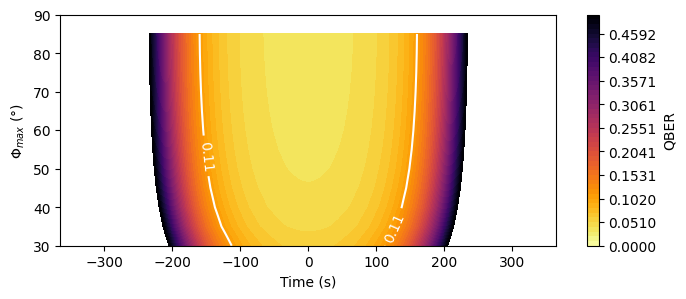

In [80]:
params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]

plt.figure(figsize=(8,3))

X, Y = np.meshgrid(loss_profiles[np.argmax([p.shape[0] for p in loss_profiles])][:,0], angle_range)
Zqber = []
max_length = np.max([p.shape[0] for p in loss_profiles])
for prof in loss_profiles:

    buffer_length = (max_length - prof[:,0].shape[0])//2
    if prof[:,0].shape[0]%2 == max_length%2:
        Zqber.append(np.pad(raw_overpass_instant(params, prof[:,1]+prof[:,2])[0], (buffer_length, buffer_length), "constant", constant_values=np.nan))
    else:
        Zqber.append(np.pad(raw_overpass_instant(params, prof[:,1]+prof[:,2])[0], (buffer_length+1, buffer_length), "constant", constant_values=np.nan))
CS=plt.contour(X, Y, Zqber,levels=[0.11], colors="white")
plt.contourf(X, Y, Zqber,levels=np.linspace(0,0.5,50), cmap="inferno_r")

plt.colorbar(label="QBER")
 
plt.ylim(30, 90)
plt.xlabel("Time (s)")
plt.clabel(CS, fontsize=10,colors='white')
plt.ylabel(rf"$\Phi_{{max}}~(\degree)$")
plt.show()

# optimize central integration window

17it [05:37, 19.83s/it]


Text(0, 0.5, 'Secret finite key length (bits)')

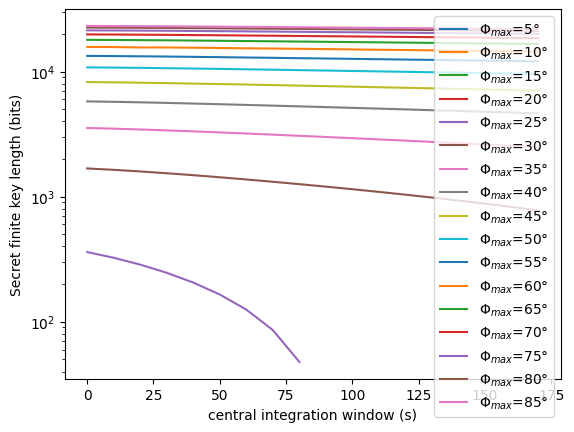

In [30]:
# without fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    E_b, E_p, m = raw_overpass_instant(params, prof[:,1]+prof[:,2])



    result = []
    for k in range(0,180,10):
        central_block = slice(k,len(prof[:,0])-k)
        CC_m_overpass_inner = m[central_block]
        avg_qber_inner = np.sum(np.array(E_b[central_block])*np.array(CC_m_overpass_inner))/np.sum(CC_m_overpass_inner)
        result += [smart_optimise(np.sum(CC_m_overpass_inner),avg_qber_inner, 1e-6, np.log2(10**8) ,1.19)*np.sum(CC_m_overpass_inner)]
    plt.plot( range(0,180,10),result[::-1], label=rf"$\Phi_{{max}}$={angle_range[i]}°")

plt.xlabel('central integration window (s)')
plt.legend()
plt.yscale('log')
plt.ylabel('Secret finite key length (bits)')

17it [1:48:02, 381.32s/it]


Text(0, 0.5, 'Secret finite key length (bits)')

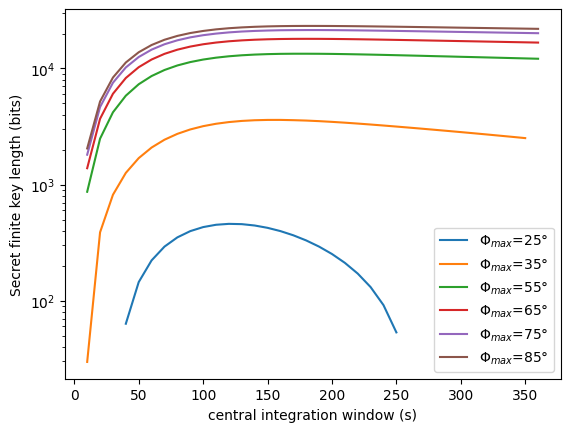

In [36]:
# without fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    if not angle_range[i] in [85,75,65,55,35, 25]:continue
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    E_b, E_p, m = raw_overpass_instant(params, prof[:,1]+prof[:,2])


    max_t =int(len(prof[:,0])/2)
    result = []
    for k in range(0,max_t,10):
        central_block = slice(int(len(prof[:,0])/2)-k,int(len(prof[:,0])/2)+k)
        CC_m_overpass_inner = m[central_block]
        avg_qber_inner = np.sum(np.array(E_b[central_block])*np.array(CC_m_overpass_inner))/np.sum(CC_m_overpass_inner)
        result += [smart_optimise(np.sum(CC_m_overpass_inner),avg_qber_inner, 1e-6, np.log2(10**8) ,1.19)*np.sum(CC_m_overpass_inner)]
    plt.plot( range(0,max_t,10),result, label=rf"$\Phi_{{max}}$={angle_range[i]}°")

plt.xlabel('central integration window (s)')
plt.legend()
plt.yscale('log')
plt.ylabel('Secret finite key length (bits)')

# two windows

100%|██████████| 37/37 [14:10<00:00, 22.99s/it]


Text(0, 0.5, 'Secret finite key length (bits)')

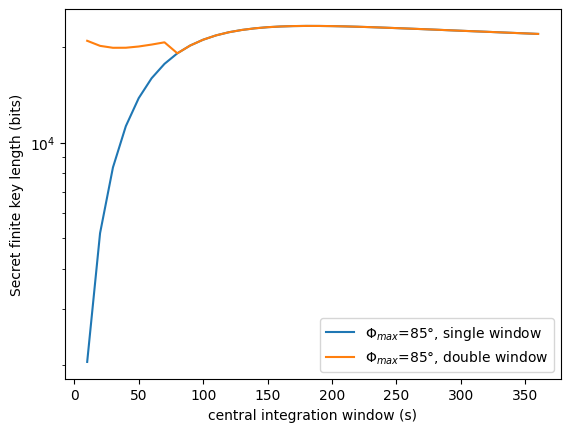

In [20]:
# without fibre
params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
for i,prof in enumerate(loss_profiles):
    if not angle_range[i] in [85]:continue
    E_b, E_p, m = raw_overpass_instant(params, prof[:,1]+prof[:,2])
    max_t =int(len(prof[:,0])/2)
    result_single = []
    result_double = []
    for k in tqdm(range(0,max_t,10)):
        central_block = slice(int(len(prof[:,0])/2)-k,int(len(prof[:,0])/2)+k)
        CC_m_overpass_inner = m[central_block]
        avg_qber_inner = np.sum(np.array(E_b[central_block])*np.array(CC_m_overpass_inner))/np.sum(CC_m_overpass_inner)
        result_single += [smart_optimise(np.sum(CC_m_overpass_inner),avg_qber_inner, 1e-6, np.log2(10**8) ,1.19)*np.sum(CC_m_overpass_inner)]
        #find the optimal integration window for the second window, assuming it is symmetric
        result_two = []
        for j in range(0,int(len(prof[:,0])/2)-k,10):
            second_block = slice(j, int(len(prof[:,0])/2)-k)
            CC_m_overpass_outer = m[second_block]
            avg_qber_outer = np.sum(np.array(E_b[second_block])*np.array(CC_m_overpass_outer))/np.sum(CC_m_overpass_outer)
            result_two += [2*smart_optimise(2*np.sum(CC_m_overpass_outer), avg_qber_outer, 1e-6, np.log2(10**8), 1.19) * np.sum(CC_m_overpass_outer)]
        result_double += [np.max(result_two)]
    plt.plot( range(0,max_t,10),result_single, label=rf"$\Phi_{{max}}$={angle_range[i]}°, single window")
    plt.plot( range(0,max_t,10),np.nan_to_num(np.array(result_double))+np.array(result_single), label=rf"$\Phi_{{max}}$={angle_range[i]}°, double window")

plt.xlabel('central integration window (s)')
plt.legend()
plt.yscale('log')
plt.ylabel('Secret finite key length (bits)')

25it [00:49,  1.97s/it]
25it [00:45,  1.81s/it]


Text(0, 0.5, 'P($\\theta$)')

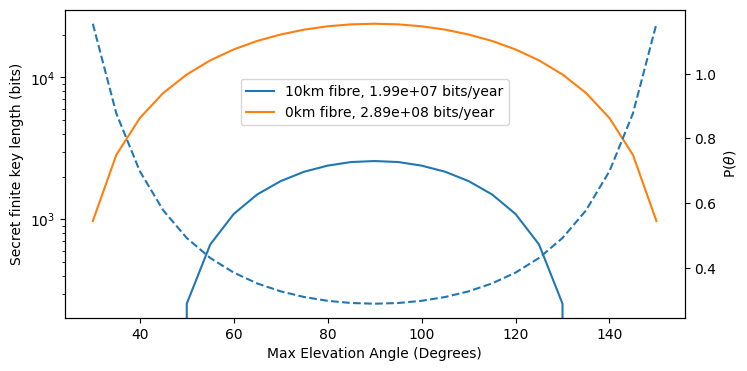

In [57]:
# with 10km fibre
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
skl = np.nan_to_num(np.array(skl))
annual_key = np.trapz(skl*1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3), angle_range) * 445.5
ax1.plot(angle_range, skl, label=f"10km fibre, {annual_key:.2e} bits/year")

# without fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
skl=np.array(skl)
annual_key = np.trapz(skl*1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3), angle_range) * 445.5
ax1.plot(angle_range, skl, label=f"0km fibre, {annual_key:.2e} bits/year")
ax1.set_xlabel("Max Elevation Angle (Degrees)")
ax1.set_ylabel("Secret finite key length (bits)")
ax1.set_yscale("log")
ax1.legend(loc='center', bbox_to_anchor=(0.5, 0.7))

ax2.plot(angle_range,1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3),"--")
ax2.set_ylabel(r"P($\theta$)")


25it [01:03,  2.52s/it]


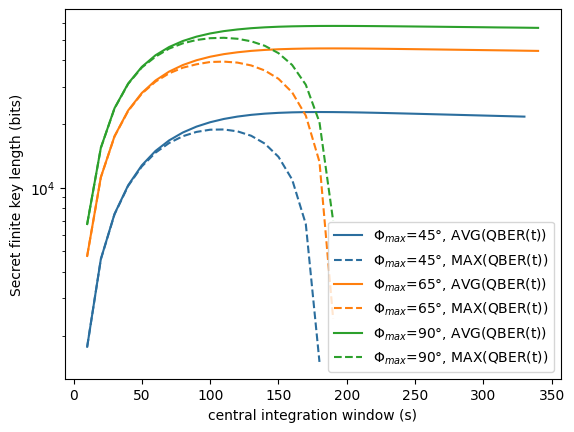

In [25]:
# without fibre
skl = []
colors= ["#2b6e9e", '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
l=0
for i,prof in tqdm(enumerate(loss_profiles)):
    if not angle_range[i] in [90,65,45]:continue
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    E_b, E_p, m = raw_overpass_instant(params, prof[:,1]+prof[:,2])


    max_t =int(len(prof[:,0])/2)
    result = []
    for k in range(0,max_t,10):
        central_block = slice(int(len(prof[:,0])/2)-k,int(len(prof[:,0])/2)+k)
        CC_m_overpass_inner = m[central_block]
        avg_qber_inner = np.sum(np.array(E_b[central_block])*np.array(CC_m_overpass_inner))/np.sum(CC_m_overpass_inner)
        result += [smart_optimise(np.sum(CC_m_overpass_inner),avg_qber_inner, 1e-6, np.log2(10**8) ,1.19)*np.sum(CC_m_overpass_inner)]
    plt.plot( range(0,max_t,10),result, label=rf"$\Phi_{{max}}$={angle_range[i]}°, AVG(QBER(t))",color=colors[l])

    # conservative estimate
    result = []
    for k in range(0,max_t,10):
        central_block = slice(int(len(prof[:,0])/2)-k,int(len(prof[:,0])/2)+k)
        CC_m_overpass_inner = m[central_block]
        if len(E_b[central_block])==0:worst_qber=0
        else:worst_qber = np.nanmax(E_b[central_block])
        result += [smart_optimise(np.sum(CC_m_overpass_inner),worst_qber, 1e-6, np.log2(10**8) ,1.19)*np.sum(CC_m_overpass_inner)]
    plt.plot( range(0,max_t,10),result, "--",label=rf"$\Phi_{{max}}$={angle_range[i]}°, MAX(QBER(t))",color=colors[l])
    l+=1
plt.xlabel('central integration window (s)')
plt.legend()
plt.yscale('log')
plt.ylabel('Secret finite key length (bits)')
plt.savefig("integration window.pdf",dpi=300)

25it [00:01, 17.11it/s]
/var/folders/qx/1r38nsxj7wn8h2snrzpp26cc0000gn/T/ipykernel_83428/2809521575.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  delta= np.trapz(deltas*1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3), angle_range) / np.trapz(1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3), angle_range)
/var/folders/qx/1r38nsxj7wn8h2snrzpp26cc0000gn/T/ipykernel_83428/2809521575.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"with 10km: {smart_optimise(np.trapz(ms, angle_range), delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * np.trapz(ms, angle_range):.2e} bits/year")


with 10km: 1.68e+08 bits/year


25it [00:01, 17.24it/s]
/var/folders/qx/1r38nsxj7wn8h2snrzpp26cc0000gn/T/ipykernel_83428/2809521575.py:29: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  delta= np.trapz(deltas*1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3), angle_range) / np.trapz(1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3), angle_range)
/var/folders/qx/1r38nsxj7wn8h2snrzpp26cc0000gn/T/ipykernel_83428/2809521575.py:30: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  print(f"without 10km: {smart_optimise(np.trapz(ms, angle_range), delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * np.trapz(ms, angle_range):.2e} bits/year")


without 10km: 7.49e+08 bits/year


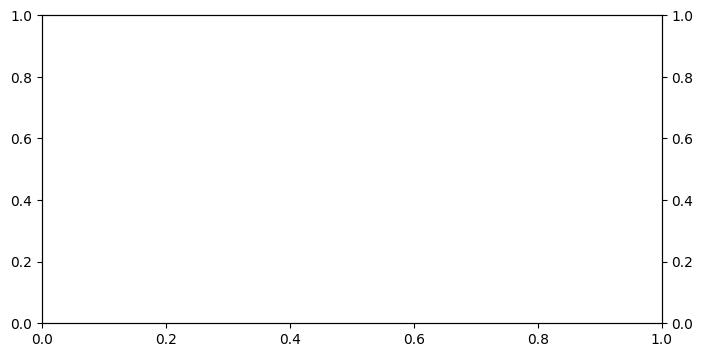

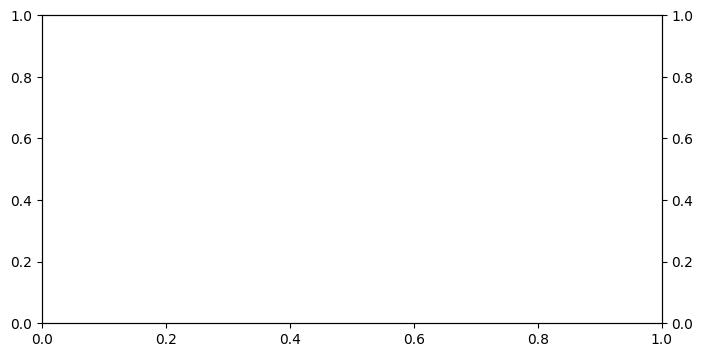

In [ ]:
# with 10km fibre
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
ms = []
deltas = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    deltas += [(qber+qx)/2]
    ms += [m]
ms = np.nan_to_num(np.array(ms))
# weigthing by the annual pass probability
ms = ms*1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3) * 445.5
delta= np.trapz(deltas*1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3), angle_range) / np.trapz(1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3), angle_range)
print(f"with 10km: {smart_optimise(np.trapz(ms, angle_range), delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * np.trapz(ms, angle_range):.2e} bits/year")
# with 10km fibre
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
ms = []
deltas = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    deltas += [(qber+qx)/2]
    ms += [m]
ms = np.nan_to_num(np.array(ms))
# weigthing by the annual pass probability
ms = ms*1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3) * 445.5
delta= np.trapz(deltas*1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3), angle_range) / np.trapz(1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3), angle_range)
print(f"without 10km: {smart_optimise(np.trapz(ms, angle_range), delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * np.trapz(ms, angle_range):.2e} bits/year")




25it [00:00, 1779.00it/s]


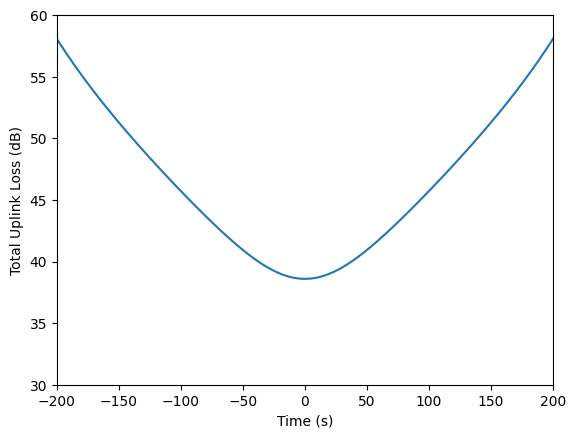

In [10]:
for i,prof in tqdm(enumerate(loss_profiles)):
    if not angle_range[i] in [90]:continue
    plt.plot(prof[:,0], prof[:,1]+prof[:,2])
    plt.ylim(30,60)
    plt.xlim(-200,200)
    plt.xlabel("Time (s)")
    plt.ylabel("Total Uplink Loss (dB)")

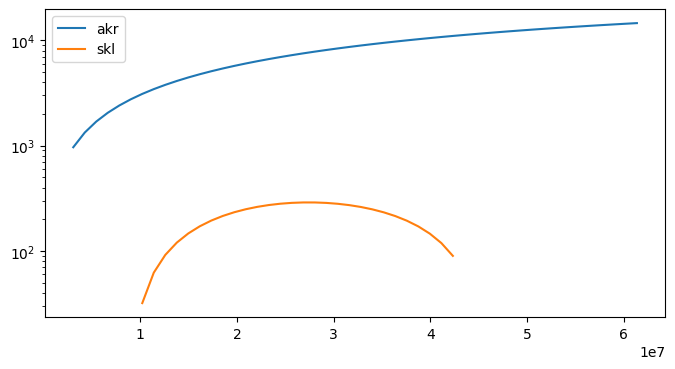

In [16]:
# for a constant integration time of 100s, not an overpass but a fixed loss (which we will sweep next)
# find the optimal power for SKL and for AKR. Also double check if the integration time matters in which is the higher one
from Lim_solver import h
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
loss = 46*np.ones(100)
powers = 6135831.8248959305*np.linspace(0.5,10,50)
akr = np.zeros_like(powers)
skl = np.zeros_like(powers)
for i,b in enumerate(powers):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, b, 1e-09]
    qber, qx, m = raw_overpass(params, loss)
    delta = (qber+qx)/2
    akr[i] =m*(1-1.19*h(delta))
    skl[i] =m*smart_optimise(m,delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19)
ax1.plot(powers,akr,label="akr")
ax1.plot(powers,skl,label="skl")
ax1.set_yscale("log")
plt.legend()

In [ ]:

# with 10km fibre
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
skl = np.nan_to_num(np.array(skl))
annual_key = np.trapz(skl*1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3), angle_range) * 445.5
ax1.plot(angle_range, skl, label=f"10km fibre, {annual_key:.2e} bits/year")

# without fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
skl=np.array(skl)
annual_key = np.trapz(skl*1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3), angle_range) * 445.5
ax1.plot(angle_range, skl, label=f"0km fibre, {annual_key:.2e} bits/year")
ax1.set_xlabel("Max Elevation Angle (Degrees)")
ax1.set_ylabel("Secret finite key length (bits)")
ax1.set_yscale("log")
ax1.legend(loc='center', bbox_to_anchor=(0.5, 0.7))

ax2.plot(angle_range,1/np.sin(angle_range*np.pi/180)**2/2/np.sqrt(3),"--")
ax2.set_ylabel(r"P($\theta$)")


91595.99249902068
329450.59989013936


# accumulating raw key of all overpasses

25it [00:08,  2.87it/s]


0.0627307811523591


25it [00:08,  2.94it/s]


0.03570733068909662


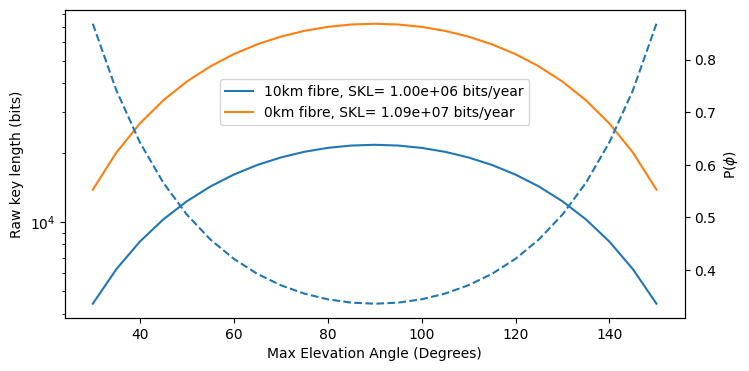

In [18]:
prob = lambda phi,R,h:(-1+R/(R+h)*np.sin(phi)/np.sqrt(1-(R*np.cos(phi)/(R+h))**2)) / (np.pi/3 - 2*np.acos(np.sqrt(3)*R/(R+h)/2))

rad_angles = np.linspace(np.pi/6,5*np.pi/6,len(angle_range))
# with 10km fibre
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
ms = []
qbers = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    ms += [m]
    qbers += [delta]
    skl=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m
ms = np.nan_to_num(np.array(ms))
m = np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)* 347.39
delta = np.trapezoid(np.array(qbers)*ms*prob(rad_angles,3575,550), rad_angles) / np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)
print(delta)
annual_key=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m

ax1.plot(angle_range, ms, label=f"10km fibre, SKL= {annual_key:.2e} bits/year")

# # without fibre

ms = []
qbers = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    ms += [m]
    qbers += [delta]
    skl=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m
ms = np.nan_to_num(np.array(ms))
m = np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)* 347.39
delta = np.trapezoid(np.array(qbers)*ms*prob(rad_angles,3575,550), rad_angles) / np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)
print(delta)
annual_key=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m

ax1.plot(angle_range, ms, label=f"0km fibre, SKL= {annual_key:.2e} bits/year")

ax1.set_xlabel("Max Elevation Angle (Degrees)")
ax1.set_ylabel("Raw key length (bits)")
ax1.set_yscale("log")
ax1.legend(loc='center', bbox_to_anchor=(0.5, 0.7))

ax2.plot(angle_range,prob(rad_angles,3575,550),"--")
ax2.set_ylabel(r"P($\phi$)")
f.savefig("annual_key_avg.pdf",dpi=300)

25it [00:01, 17.12it/s]


0.0627307811523591


  0%|          | 0/35 [00:00<?, ?it/s]/Users/thomasjaeken/Heriot-Watt University Team Dropbox/RES_EPS_EMQL/projects/Optical ground station/__software__/finite_key/Lim_solver.py:20: RuntimeWarning: invalid value encountered in log2
  l = 2*np.log2(2*(eps_qkd-2**(-t)-2*eps_pe)) + n*(1-h(delta+nu)) - r - t
/Users/thomasjaeken/Heriot-Watt University Team Dropbox/RES_EPS_EMQL/projects/Optical ground station/__software__/finite_key/Lim_solver.py:57: RuntimeWarning: Method Nelder-Mead cannot handle constraints.
  result = minimize(neg_objective,x0=init_vals,constraints=constraints,args=(delta, m, eps_qkd, t, f),method="Nelder-Mead")
100%|██████████| 35/35 [00:09<00:00,  3.51it/s]
25it [00:01, 16.88it/s]


0.03570733068909662


 31%|███▏      | 11/35 [00:03<00:06,  3.52it/s]/Users/thomasjaeken/Heriot-Watt University Team Dropbox/RES_EPS_EMQL/projects/Optical ground station/__software__/finite_key/Lim_solver.py:11: RuntimeWarning: invalid value encountered in log2
  return -x*np.log2(x) - (1-x)*np.log2(1-x)
100%|██████████| 35/35 [00:09<00:00,  3.50it/s]


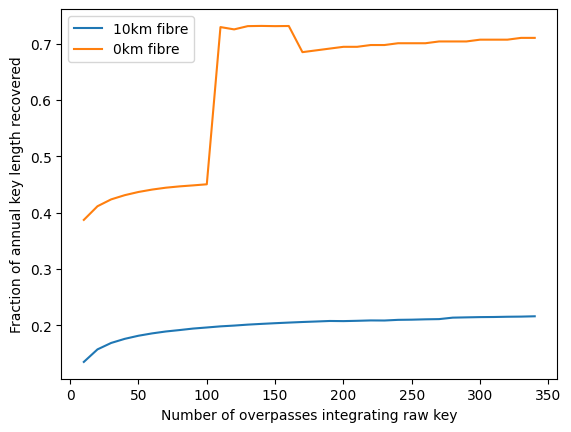

In [55]:
prob = lambda phi,R,h:(-1+R/(R+h)*np.sin(phi)/np.sqrt(1-(R*np.cos(phi)/(R+h))**2)) / (np.pi/3 - 2*np.acos(np.sqrt(3)*R/(R+h)/2))

rad_angles = np.linspace(np.pi/6,5*np.pi/6,len(angle_range))
# with 10km fibre
ms = []
qbers = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    ms += [m]
    qbers += [delta]
    # skl=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m
ms = np.nan_to_num(np.array(ms))
overpasses = np.arange(348,step=10)  # normalize to 1 over the range
m = np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)*overpasses
delta = np.trapezoid(np.array(qbers)*ms*prob(rad_angles,3575,550), rad_angles) / np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)
print(delta)
annual_key_fraction=[]
for m_sample in tqdm(m):
    annual_key_fraction += [smart_optimise(m_sample, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19)]
plt.plot(overpasses,annual_key_fraction ,label="10km fibre")
# with 10km fibre
ms = []
qbers = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    ms += [m]
    qbers += [delta]
    # skl=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m
ms = np.nan_to_num(np.array(ms))
overpasses = np.arange(348,step=10)  # normalize to 1 over the range
m = np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)*overpasses
delta = np.trapezoid(np.array(qbers)*ms*prob(rad_angles,3575,550), rad_angles) / np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)
print(delta)
annual_key_fraction=[]
for m_sample in tqdm(m):
    annual_key_fraction += [smart_optimise(m_sample, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19)]
plt.plot(overpasses,annual_key_fraction ,label="0km fibre")
plt.xlabel("Number of overpasses integrating raw key")
plt.ylabel("Fraction of annual key length recovered")
plt.legend()

# compare annual keys for micius and qeyssat


In [6]:
prob = lambda phi,R,h:(-1+R/(R+h)*np.sin(phi)/np.sqrt(1-(R*np.cos(phi)/(R+h))**2)) / (np.pi/3 - 2*np.acos(np.sqrt(3)*R/(R+h)/2))

1.26579805859825


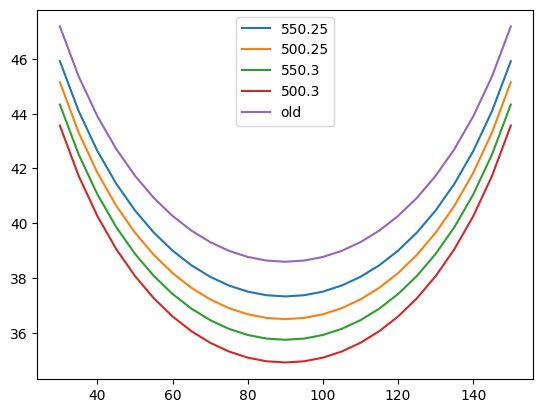

In [83]:
new = [np.loadtxt(f"550000m_0m_0.25m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"550000m_0m_0.25m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]
plt.plot(angle_range, [np.min(prof[:,1]+prof[:,2]) for prof in new], label="550.25")
neww = [np.loadtxt(f"500000m_0m_0.25m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"500000m_0m_0.25m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]
plt.plot(angle_range, [np.min(prof[:,1]+prof[:,2]) for prof in neww], label="500.25")
neww = [np.loadtxt(f"550000m_0m_0.3m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"550000m_0m_0.3m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]
plt.plot(angle_range, [np.min(prof[:,1]+prof[:,2]) for prof in neww], label="550.3")
neww = [np.loadtxt(f"500000m_0m_0.3m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"500000m_0m_0.3m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]
plt.plot(angle_range, [np.min(prof[:,1]+prof[:,2]) for prof in neww], label="500.3")
plt.plot(angle_range, [np.min(prof[:,1]+prof[:,2]) for prof in old], label="old")
print(np.min([np.min(prof[:,1]+prof[:,2]) for prof in old])-np.min([np.min(prof[:,1]+prof[:,2]) for prof in new]))
plt.legend()

# Annual secure key each overpass

25it [00:08,  2.82it/s]
25it [00:08,  2.86it/s]


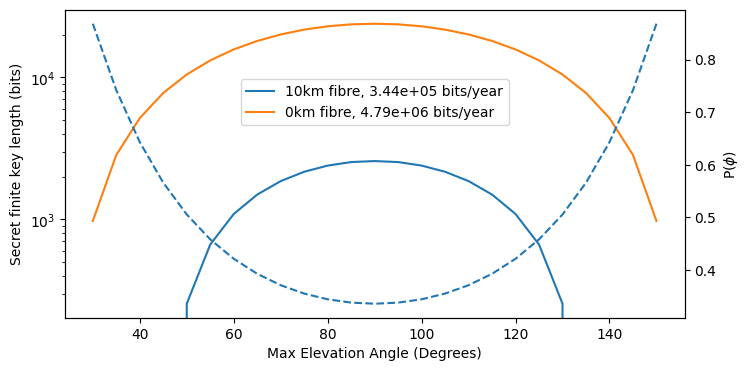

In [47]:
#550000m_0m_0.25m
angle_range=np.arange(30, 155,5)
loss_profiles = [np.loadtxt(f"550000m_0m_0.25m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"550000m_0m_0.25m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]
rad_angles = np.linspace(np.pi/6,5*np.pi/6,len(angle_range))
# with 10km fibre
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2]+1.26579805859825)
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
skl = np.nan_to_num(np.array(skl))

annual_key = np.trapezoid(skl*prob(rad_angles,3575,550), rad_angles) * 389.8
ax1.plot(angle_range, skl, label=f"10km fibre, {annual_key:.2e} bits/year")

# without fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2]+1.26579805859825)
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
skl=np.array(skl)
annual_key = np.trapezoid(skl*prob(rad_angles,3575,550), rad_angles) * 389.8
ax1.plot(angle_range, skl, label=f"0km fibre, {annual_key:.2e} bits/year")
ax1.set_xlabel("Max Elevation Angle (Degrees)")
ax1.set_ylabel("Secret finite key length (bits)")
ax1.set_yscale("log")
ax1.legend(loc='center', bbox_to_anchor=(0.5, 0.7))

ax2.plot(angle_range,prob(rad_angles,3575,550),"--")
ax2.set_ylabel(r"P($\phi$)")
f.savefig("skl_for_schematic_plot.pdf",dpi=300)


25it [00:08,  2.80it/s]
25it [00:08,  2.89it/s]


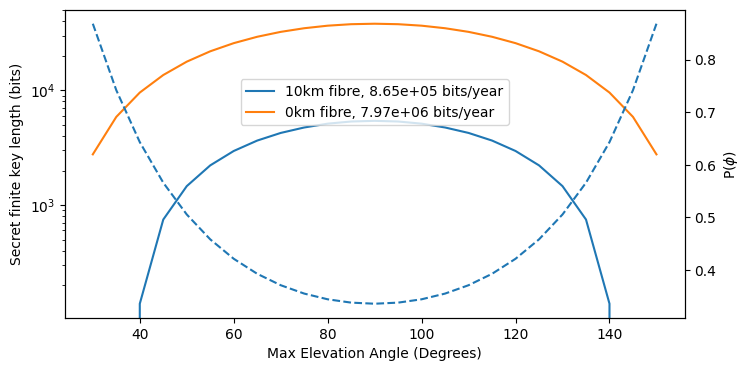

In [ ]:
#550000m_0m_0.3m
angle_range=np.arange(30, 155,5)
loss_profiles = [np.loadtxt(f"550000m_0m_0.3m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"550000m_0m_0.3m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]
# plt.plot(old[15][:,0], old[15][:,1]+old[15][:,2], label="old model")
# plt.plot(old[15][:,0], new[15][:,1]+new[15][:,2], label="new model")
# plt.legend()
# plt.ylim(38,40)
# with 10km fibre
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2]+1.26579805859825)
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
skl = np.nan_to_num(np.array(skl))

annual_key = np.trapezoid(skl*prob(rad_angles,3575,550), rad_angles) * 389.8
ax1.plot(angle_range, skl, label=f"10km fibre, {annual_key:.2e} bits/year")

# without fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2]+1.26579805859825)
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
skl=np.array(skl)
annual_key = np.trapezoid(skl*prob(rad_angles,3575,550), rad_angles) * 389.8
ax1.plot(angle_range, skl, label=f"0km fibre, {annual_key:.2e} bits/year")
ax1.set_xlabel("Max Elevation Angle (Degrees)")
ax1.set_ylabel("Secret finite key length (bits)")
ax1.set_yscale("log")
ax1.legend(loc='center', bbox_to_anchor=(0.5, 0.7))

ax2.plot(angle_range,prob(rad_angles,3575,550),"--")
ax2.set_ylabel(r"P($\phi$)")



25it [00:09,  2.77it/s]
25it [00:08,  2.79it/s]


Text(0, 0.5, 'P($\\phi$)')

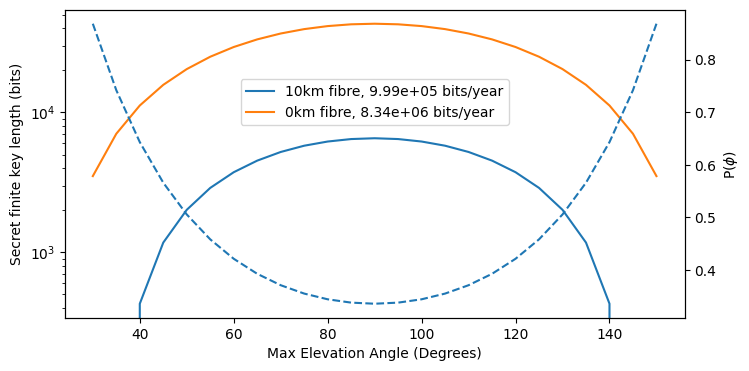

In [23]:
#500000m_0m_0.3m
angle_range=np.arange(30, 155,5)
loss_profiles = [np.loadtxt(f"500000m_0m_0.3m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"500000m_0m_0.3m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]
# plt.plot(old[15][:,0], old[15][:,1]+old[15][:,2], label="old model")
# plt.plot(old[15][:,0], new[15][:,1]+new[15][:,2], label="new model")
# plt.legend()
# plt.ylim(38,40)
# with 10km fibre
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2]+1.26579805859825)
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
skl = np.nan_to_num(np.array(skl))

annual_key = np.trapezoid(skl*prob(rad_angles,3575,500), rad_angles) * 359.4
ax1.plot(angle_range, skl, label=f"10km fibre, {annual_key:.2e} bits/year")

# without fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2]+1.26579805859825)
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
skl=np.array(skl)
annual_key = np.trapezoid(skl*prob(rad_angles,3575,500), rad_angles) * 359.4
ax1.plot(angle_range, skl, label=f"0km fibre, {annual_key:.2e} bits/year")
ax1.set_xlabel("Max Elevation Angle (Degrees)")
ax1.set_ylabel("Secret finite key length (bits)")
ax1.set_yscale("log")
ax1.legend(loc='center', bbox_to_anchor=(0.5, 0.7))

ax2.plot(angle_range,prob(rad_angles,3575,550),"--")
ax2.set_ylabel(r"P($\phi$)")


25it [00:09,  2.78it/s]
25it [00:08,  2.94it/s]


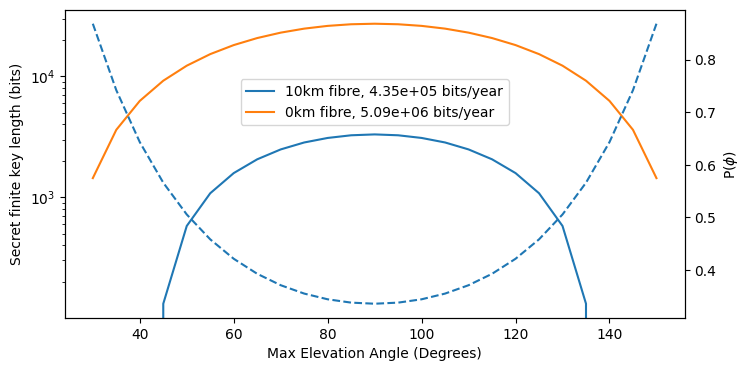

In [45]:
#500000m_0m_0.25m
angle_range=np.arange(30, 155,5)
loss_profiles = [np.loadtxt(f"500000m_0m_0.25m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"500000m_0m_0.25m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]
# plt.plot(old[15][:,0], old[15][:,1]+old[15][:,2], label="old model")
# plt.plot(old[15][:,0], new[15][:,1]+new[15][:,2], label="new model")
# plt.legend()
# plt.ylim(38,40)
# with 10km fibre
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2]+1.26579805859825)
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
skl = np.nan_to_num(np.array(skl))

annual_key = np.trapezoid(skl*prob(rad_angles,3575,500), rad_angles) * 359.4
ax1.plot(angle_range, skl, label=f"10km fibre, {annual_key:.2e} bits/year")

# without fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2]+1.26579805859825)
    delta = (qber+qx)/2
    skl+=[smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m]
skl=np.array(skl)
annual_key = np.trapezoid(skl*prob(rad_angles,3575,500), rad_angles) * 359.4
ax1.plot(angle_range, skl, label=f"0km fibre, {annual_key:.2e} bits/year")
ax1.set_xlabel("Max Elevation Angle (Degrees)")
ax1.set_ylabel("Secret finite key length (bits)")
ax1.set_yscale("log")
ax1.legend(loc='center', bbox_to_anchor=(0.5, 0.7))

ax2.plot(angle_range,prob(rad_angles,3575,550),"--")
ax2.set_ylabel(r"P($\phi$)")
f.savefig("skl_for_schematic_plot.pdf",dpi=300)


# Annual secure key accumulated raw key

25it [00:08,  2.84it/s]


0.04862695171922487


25it [00:08,  2.83it/s]


0.031164303353537974


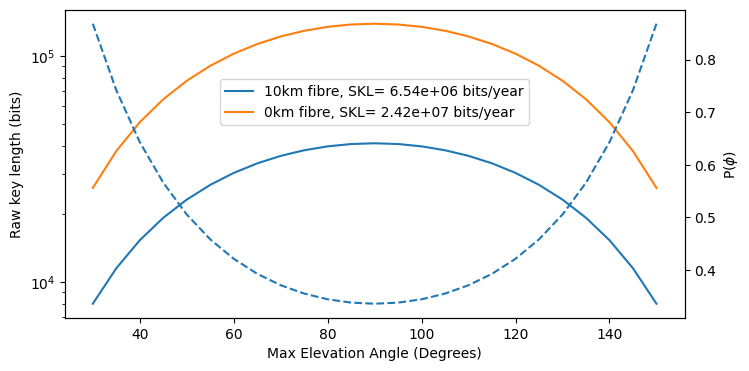

In [11]:
loss_profiles = [np.loadtxt(f"550000m_0m_0.3m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"550000m_0m_0.3m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]

# with 10km fibre
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
ms = []
qbers = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    ms += [m]
    qbers += [delta]
    skl=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m
ms = np.nan_to_num(np.array(ms))
m = np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)* 389.8
delta = np.trapezoid(np.array(qbers)*ms*prob(rad_angles,3575,550), rad_angles) / np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)
print(delta)
annual_key=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m

ax1.plot(angle_range, ms, label=f"10km fibre, SKL= {annual_key:.2e} bits/year")

# # without fibre

ms = []
qbers = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    ms += [m]
    qbers += [delta]
    skl=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m
ms = np.nan_to_num(np.array(ms))
m = np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)* 389.8
delta = np.trapezoid(np.array(qbers)*ms*prob(rad_angles,3575,550), rad_angles) / np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)
print(delta)
annual_key=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m

ax1.plot(angle_range, ms, label=f"0km fibre, SKL= {annual_key:.2e} bits/year")

ax1.set_xlabel("Max Elevation Angle (Degrees)")
ax1.set_ylabel("Raw key length (bits)")
ax1.set_yscale("log")
ax1.legend(loc='center', bbox_to_anchor=(0.5, 0.7))

ax2.plot(angle_range,prob(rad_angles,3575,550),"--")
ax2.set_ylabel(r"P($\phi$)")
f.savefig("annual_key_avg.pdf",dpi=300)

25it [00:09,  2.70it/s]


0.04654477287031315


25it [00:08,  2.79it/s]


0.030504265924162947


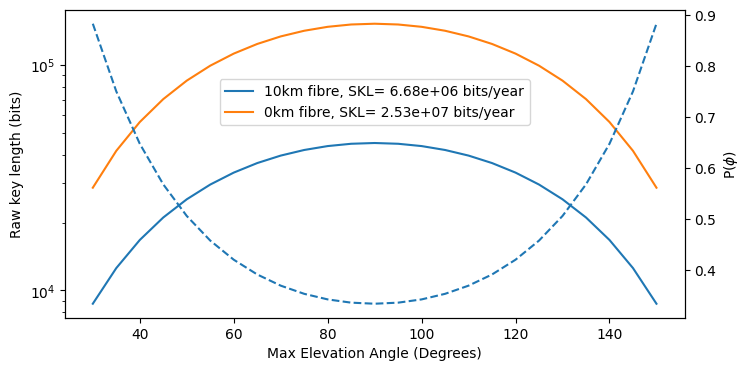

In [21]:
loss_profiles = [np.loadtxt(f"500000m_0m_0.3m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"500000m_0m_0.3m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]

# with 10km fibre
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
ms = []
qbers = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    ms += [m]
    qbers += [delta]
    skl=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m
ms = np.nan_to_num(np.array(ms))
m = np.trapezoid(ms*prob(rad_angles,3575,500), rad_angles)* 359.4
delta = np.trapezoid(np.array(qbers)*ms*prob(rad_angles,3575,500), rad_angles) / np.trapezoid(ms*prob(rad_angles,3575,500), rad_angles)
print(delta)
annual_key=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m

ax1.plot(angle_range, ms, label=f"10km fibre, SKL= {annual_key:.2e} bits/year")

# # without fibre

ms = []
qbers = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    ms += [m]
    qbers += [delta]
    skl=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m
ms = np.nan_to_num(np.array(ms))
m = np.trapezoid(ms*prob(rad_angles,3575,500), rad_angles)* 359.4
delta = np.trapezoid(np.array(qbers)*ms*prob(rad_angles,3575,500), rad_angles) / np.trapezoid(ms*prob(rad_angles,3575,500), rad_angles)
print(delta)
annual_key=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m

ax1.plot(angle_range, ms, label=f"0km fibre, SKL= {annual_key:.2e} bits/year")

ax1.set_xlabel("Max Elevation Angle (Degrees)")
ax1.set_ylabel("Raw key length (bits)")
ax1.set_yscale("log")
ax1.legend(loc='center', bbox_to_anchor=(0.5, 0.7))

ax2.plot(angle_range,prob(rad_angles,3575,500),"--")
ax2.set_ylabel(r"P($\phi$)")
f.savefig("annual_key_avg.pdf",dpi=300)

25it [00:08,  2.84it/s]


0.05244436085683755


25it [00:09,  2.75it/s]


0.032381449252485366


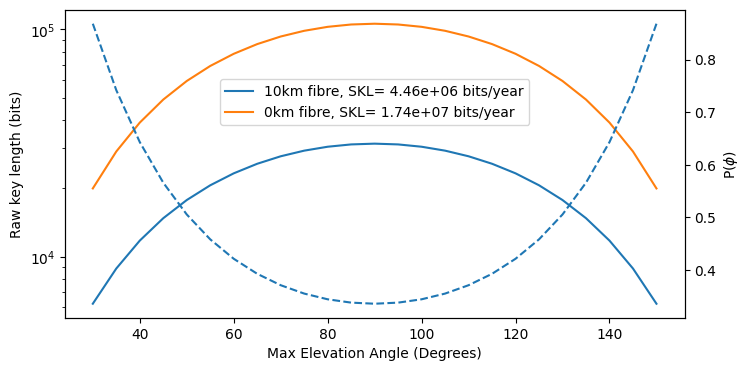

In [20]:
loss_profiles = [np.loadtxt(f"500000m_0m_0.25m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"500000m_0m_0.25m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]

# with 10km fibre
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
ms = []
qbers = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    ms += [m]
    qbers += [delta]
    skl=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m
ms = np.nan_to_num(np.array(ms))
m = np.trapezoid(ms*prob(rad_angles,3575,500), rad_angles)* 359.4
delta = np.trapezoid(np.array(qbers)*ms*prob(rad_angles,3575,500), rad_angles) / np.trapezoid(ms*prob(rad_angles,3575,500), rad_angles)
print(delta)
annual_key=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m

ax1.plot(angle_range, ms, label=f"10km fibre, SKL= {annual_key:.2e} bits/year")

# # without fibre

ms = []
qbers = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    ms += [m]
    qbers += [delta]
    skl=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m
ms = np.nan_to_num(np.array(ms))
m = np.trapezoid(ms*prob(rad_angles,3575,500), rad_angles)* 359.4
delta = np.trapezoid(np.array(qbers)*ms*prob(rad_angles,3575,500), rad_angles) / np.trapezoid(ms*prob(rad_angles,3575,500), rad_angles)
print(delta)
annual_key=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m

ax1.plot(angle_range, ms, label=f"0km fibre, SKL= {annual_key:.2e} bits/year")

ax1.set_xlabel("Max Elevation Angle (Degrees)")
ax1.set_ylabel("Raw key length (bits)")
ax1.set_yscale("log")
ax1.legend(loc='center', bbox_to_anchor=(0.5, 0.7))

ax2.plot(angle_range,prob(rad_angles,3575,550),"--")
ax2.set_ylabel(r"P($\phi$)")
f.savefig("annual_key_avg.pdf",dpi=300)

25it [00:09,  2.55it/s]


0.055388936763956974


25it [00:08,  2.86it/s]


0.0333265877076924


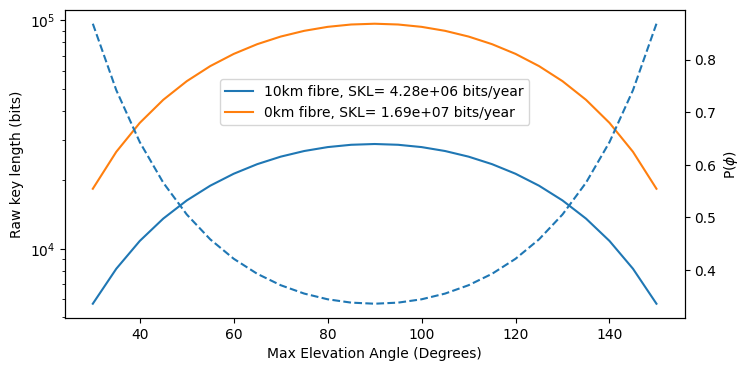

In [14]:
loss_profiles = [np.loadtxt(f"550000m_0m_0.25m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"550000m_0m_0.25m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]

# with 10km fibre
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
ms = []
qbers = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305, 1e-09]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    ms += [m]
    qbers += [delta]
    skl=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m
ms = np.nan_to_num(np.array(ms))
m = np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)* 389.8
delta = np.trapezoid(np.array(qbers)*ms*prob(rad_angles,3575,550), rad_angles) / np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)
print(delta)
annual_key=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m

ax1.plot(angle_range, ms, label=f"10km fibre, SKL= {annual_key:.2e} bits/year")

# # without fibre

ms = []
qbers = []
for i,prof in tqdm(enumerate(loss_profiles)):
    params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633, 4e-10]
    qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
    delta = (qber+qx)/2
    ms += [m]
    qbers += [delta]
    skl=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m
ms = np.nan_to_num(np.array(ms))
m = np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)* 389.8
delta = np.trapezoid(np.array(qbers)*ms*prob(rad_angles,3575,550), rad_angles) / np.trapezoid(ms*prob(rad_angles,3575,550), rad_angles)
print(delta)
annual_key=smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m

ax1.plot(angle_range, ms, label=f"0km fibre, SKL= {annual_key:.2e} bits/year")

ax1.set_xlabel("Max Elevation Angle (Degrees)")
ax1.set_ylabel("Raw key length (bits)")
ax1.set_yscale("log")
ax1.legend(loc='center', bbox_to_anchor=(0.5, 0.7))

ax2.plot(angle_range,prob(rad_angles,3575,550),"--")
ax2.set_ylabel(r"P($\phi$)")
f.savefig("annual_key_avg.pdf",dpi=300)

# heatmap for power vs elevation angle

In [61]:
angle_range=np.arange(30, 151,1)
loss_profiles = [np.loadtxt(f"550000m_0m_0.25m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"550000m_0m_0.25m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]

powers=np.linspace(0.1,10,50)

# # without fibre
skls=[]
angles_skl=[]
pwrs_skl =[]
akrs = []
angles_akr=[]
pwrs_akr =[]
ratios = []

opt_pow_akr = []
opt_pow_skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    if angle_range[i]>90:continue
    opt_akr=0
    opt_akr_pow = np.nan
    opt_skl=0
    opt_skl_pow = np.nan
    for power in powers:
        
        params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305*power, 1e-09]
        qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
        delta = (qber+qx)/2
        m/=2 # sifting!
        skl = smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m
        akr = (1-1.19*h(qber)-h(qx))/2 * m
        
        if akr>0:
            pwrs_akr +=[power]
            angles_akr +=[angle_range[i]]
            akrs+=[akr]
            if akr>opt_akr:
                opt_akr = akr
                opt_akr_pow= power
            if skl>0:
                pwrs_skl +=[power]
                angles_skl +=[angle_range[i]]
                skls+=[skl]
                if skl>opt_skl:
                    opt_skl = skl
                    opt_skl_pow = power
                #whenever skl is pos akr is pos too
                ratios+=[skl/akr]

    opt_pow_akr += [opt_akr_pow]
    opt_pow_skl += [opt_skl_pow]
# fig = plt.figure(figsize=(2.5, 1.8))
# plot_area = fig.add_axes([0, 0, 1, 1])
# t=plot_area.tricontourf(angles, pwrs, np.log10(skls), levels=10, cmap="Blues")
# fig.colorbar(t)
# plot_area.set_xlim(30,90)
# plot_area.set_ylabel('Power (mW)',fontsize=10)
# plot_area.set_xlabel(rf'angle ($^\circ$)',fontsize=10)

# plt.savefig("powers_vs_skl.pdf",dpi=300,bbox_inches="tight")
# plt.show()

121it [18:17,  9.07s/it]


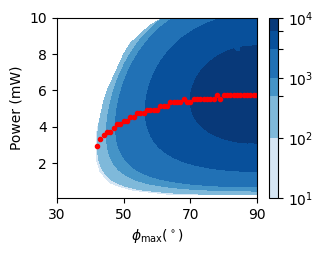

In [65]:
fig = plt.figure(figsize=(2.5, 1.8))
from matplotlib.colors import LogNorm
plot_area = fig.add_axes([0, 0, 1, 1])
t=plot_area.tricontourf(angles_skl, pwrs_skl,skls, cmap="Blues",norm = LogNorm(),levels=[10, 100, 500,1000,3000,6000,10000])
plot_area.set_xlim(30,90)
plot_area.set_xticks([30,50,70,90])
plot_area.plot(np.arange(30, 91,1),opt_pow_skl, ".",color="red")
fig.colorbar(t)
plot_area.set_ylim(0.1,10)
plot_area.set_ylabel('Power (mW)',fontsize=10)
plot_area.set_xlabel(r'$\phi_{\text{max}} (^\circ$)',fontsize=10)

# plt.savefig("powers_vs_skl.pdf",dpi=300,bbox_inches="tight")
plt.show()

100%|██████████| 10/10 [00:00<00:00, 16.49it/s]
121it [00:37,  3.27it/s]


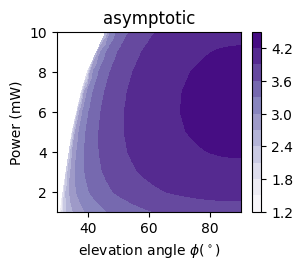

In [ ]:
angle_range = np.arange(30, 151,1)
loss_profiles = [np.loadtxt(f"550000m_0m_0.25m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"550000m_0m_0.25m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]
grain=10
powers=np.linspace(0.1,10,50)
h=lambda x: -x*np.log2(x)-(1-x)*np.log2(1-x)
# # without fibre
akrs=[]
angles=[]
pwrs =[]
opt_powers = np.nan*np.ones(len())
for i,prof in tqdm(enumerate(loss_profiles)):
    if angle_range[i]>90:continue
    for power in tqdm(powers):
        params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305*power, 1e-09]
        qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2])
        
        akr = (1-1.19*h(qber)-h(qx))/2 * m
        if akr>0:
            pwrs +=[power]
            angles +=[angle_range[i]]
            akrs+=[akr]
fig = plt.figure(figsize=(2.3, 1.8))
plot_area = fig.add_axes([0, 0, 1, 1])
t=plot_area.tricontourf(angles, pwrs, np.log10(akrs), levels=10, cmap="Purples")
fig.colorbar(t)
plot_area.set_title("asymptotic")
plot_area.set_xlim(30,90)
plot_area.set_ylabel('Power (mW)',fontsize=10)
plot_area.set_xlabel(rf'elevation angle $\phi (^\circ)$',fontsize=10)

# plt.savefig("powers_vs_akr.pdf",dpi=300,bbox_inches="tight")
plt.show()

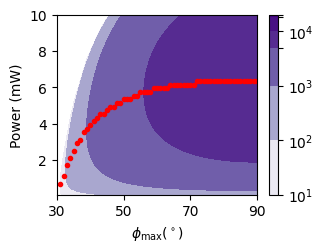

In [64]:
fig = plt.figure(figsize=(2.5, 1.8))
from matplotlib.colors import LogNorm
plot_area = fig.add_axes([0, 0, 1, 1])
t=plot_area.tricontourf(angles_akr, pwrs_akr,akrs, cmap="Purples",norm = LogNorm(),levels=[10, 100,1000,5000,10000,18000,20000])
plot_area.set_xlim(30,90)
plot_area.set_xticks([30,50,70,90])
plot_area.set_ylim(0.1,10)
plot_area.plot(np.arange(30, 91,1),opt_pow_akr, ".",color="red")
fig.colorbar(t)
plot_area.set_ylabel('Power (mW)',fontsize=10)
plot_area.set_xlabel(r'$\phi_{\text{max}} (^\circ$)',fontsize=10)

# plt.savefig("powers_vs_akr.pdf",dpi=300,bbox_inches="tight")
plt.show()

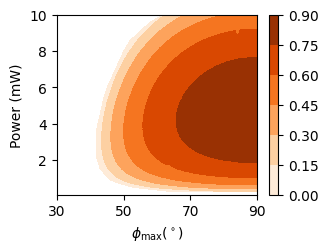

In [66]:
fig = plt.figure(figsize=(2.5, 1.8))
from matplotlib.colors import LogNorm
plot_area = fig.add_axes([0, 0, 1, 1])
t=plot_area.tricontourf(angles_skl, pwrs_skl,ratios, cmap="Oranges")
plot_area.set_xlim(30,90)
plot_area.set_xticks([30,50,70,90])
fig.colorbar(t)
plot_area.set_ylim(0.1,10)
plot_area.set_ylabel('Power (mW)',fontsize=10)
plot_area.set_xlabel(r'$\phi_{\text{max}} (^\circ$)',fontsize=10)

# plt.savefig("powers_vs_skl.pdf",dpi=300,bbox_inches="tight")
plt.show()

# optimize power per overpass

25it [01:26,  3.46s/it]
0it [00:00, ?it/s]

1.0
2.0
3.0
4.0
5.0


1it [00:03,  3.46s/it]

1.0
2.0
3.0
4.0
5.0
6.0


2it [00:07,  3.51s/it]

...

1.0
2.0
3.0
4.0
5.0
6.0


24it [01:30,  3.69s/it]

1.0
2.0
3.0
4.0
5.0


25it [01:34,  3.76s/it]


Text(0, 0.5, 'P($\\phi$)')

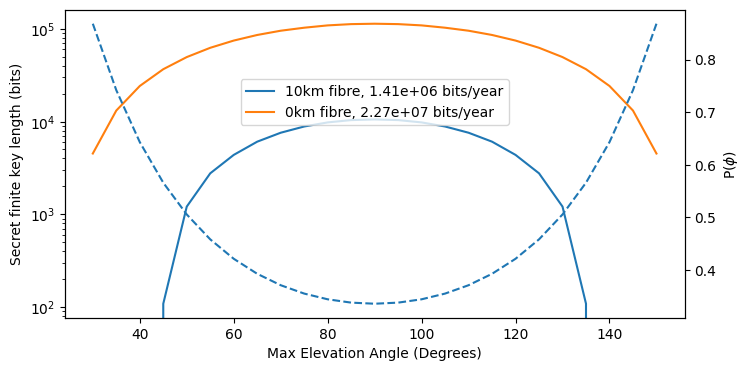

In [ ]:
#550000m_0m_0.25m
angle_range=np.arange(30, 155,5)
powers=np.linspace(1,10,10)
loss_profiles = [np.loadtxt(f"550000m_0m_0.25m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"550000m_0m_0.25m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]
rad_angles = np.linspace(np.pi/6,5*np.pi/6,len(angle_range))
# with 10km fibre
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    current_best = 0
    for power in powers:
        params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305*power, 1e-09]
        qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2]+1.26579805859825)
        delta = (qber+qx)/2
        current = smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m
        if current> current_best:
            current_best=current
    skl+=[current_best]
skl = np.nan_to_num(np.array(skl))

annual_key = np.trapezoid(skl*prob(rad_angles,3575,550), rad_angles) * 389.8
ax1.plot(angle_range, skl, label=f"10km fibre, {annual_key:.2e} bits/year")

# without fibre
skl = []
for i,prof in tqdm(enumerate(loss_profiles)):
    current_best = 0
    for power in powers:
        params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633*power, 4e-10]
        qber, qx, m = raw_overpass(params, prof[:,1]+prof[:,2]+1.26579805859825)
        delta = (qber+qx)/2
        current = smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m
        if current> current_best:
            current_best=current
            # print(power)
    skl+=[current_best]
skl=np.array(skl)
annual_key = np.trapezoid(skl*prob(rad_angles,3575,550), rad_angles) * 389.8
ax1.plot(angle_range, skl, label=f"0km fibre, {annual_key:.2e} bits/year")
ax1.set_xlabel("Max Elevation Angle (Degrees)")
ax1.set_ylabel("Secret finite key length (bits)")
ax1.set_yscale("log")
ax1.legend(loc='center', bbox_to_anchor=(0.5, 0.7))

ax2.plot(angle_range,prob(rad_angles,3575,550),"--")
ax2.set_ylabel(r"P($\phi$)")
# f.savefig("skl_for_schematic_plot.pdf",dpi=300)
